In [10]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict,Literal


In [11]:
class State(TypedDict):
    a:int
    b:int
    c:int
    result:int
    typ:str

In [12]:
def result(state:State):
    state['result']=state['a']+state["b"]+state['c']
    return state
def pos(state:State):
    state["typ"]="+"
    return state
def neg(state:State):
    state["typ"]="-"
    return state
def nut(state:State):
    state["typ"]="0"
    return state

def condition(state:State) -> Literal["pos","neg","nut"]:
    res=state['result']
    if(res<0):    
        return "neg"
    elif(res>0):
        return "pos"
    else:
        return "nut"

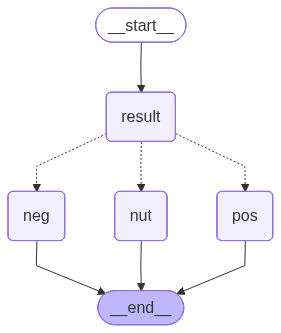

In [20]:
graph=StateGraph(State)

graph.add_node("result",result)
graph.add_node("pos",pos)
graph.add_node("nut",nut)
graph.add_node("neg",neg)

graph.add_edge(START,"result")
graph.add_conditional_edges("result",condition)
graph.add_edge("pos",END)
graph.add_edge("neg",END)
graph.add_edge("nut",END)
wf=graph.compile()
graph.compile()

In [21]:
print(wf.invoke({"a":-1,"b":2,"c":30}))

{'a': -1, 'b': 2, 'c': 30, 'result': 31, 'typ': '+'}
